# The ±60° WAC_EMP edge-brightening correction

WAC_EMP's archive splits each hemisphere into an equirectangular tile (0-60°) and a
polar-stereographic tile (60-90°). Both tiles carry a real edge-brightening defect right at that
±60° boundary, baked into the archived pixels themselves: the equirect tile's last valid native row
runs anomalously bright, and the polar tile has a smaller damped-oscillation overshoot/undershoot in
its own last few pixels before real coverage ends. Wherever a footprint straddles the boundary,
`ortho_wac_emp.reproject_wac_emp_reflectance_to_local_grid` mosaics the two tiles onto one grid, and
bilinear resampling smears that bright native row into a visible horizontal band in the merged
reflectance (`ortho_wac_emp.tif`, the texture `hapke.despeckle_and_shade_ortho` later relights).

`wac_emp_edge_correction.py` fixes this: mask the equirect tile's bad row outright, mask and model
the polar tile's edge (a damped cosine fit live per window, not one fixed number per hemisphere,
since the real amplitude varies more than 2x between windows at the same latitude), and close the
small coverage gap the masking opens. This notebook shows the seam before and after correction,
shows what the correction does to each tile's own near-boundary profile, and validates the fix end
to end with an independent tool (ASP `dem_mosaic`, not this project's own merge code) across both
hemispheres.

Two known-bad `trntest1` south entries and `trntest2`'s worst known north entry anchor this
notebook -- all three already exist on disk from earlier population runs, so everything below is
read-only against cached data plus scratch-directory intermediates, no fetch or camera build needed.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.warp import Resampling
from rasterio.warp import transform as warp_transform
from rasterio.windows import Window
from rasterio.windows import transform as window_transform

import trntest
from trntest import cache, wac_emp_edge_correction
from trntest.config import MOON_RADIUS_M
from trntest.geo_utils import geographic_crs, local_orthographic_crs, merge_local_grid_arrays
from trntest.ortho_wac_emp import _reproject_one_wac_emp_tile_to_array, wac_emp_tile_ids_for_bbox
from trntest.subprocess_utils import run_quiet
from trntest.wac_emp_edge_correction import GAP_FILL_MAX_RADIUS_PX, eligible_gap_fill_mask, fill_nearby_gaps

config = trntest.load_config()

_REAL_REFLECTANCE_MIN = -1e30  # matches wac_emp_edge_correction's own convention

# (dataset name, product ID, hemisphere label) -- two known-bad trntest1 south entries, plus
# trntest2's worst known north entry (15.6x the typical row-to-row jump, the highest of the 11
# affected north entries docs/proposed-tasks/open-items.md tracks).
ENTRIES = [
    ("trntest1", "M1314469291CE", "south"),  # -60.738 deg
    ("trntest1", "M1314314993CE", "south"),  # -60.619 deg
    ("trntest2", "M1309348984CE", "north"),  # +60 deg boundary
]
datasets = {name: trntest.TrnTestDataSet.open(config.output_dir / name, config) for name, _, _ in ENTRIES}
geo_crs = geographic_crs()
CROP_SIZE = 200
SCRATCH_DIR = config.scratch_dir / "wac_emp_seam_correction"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)


def label(product_id: str, hemisphere: str) -> str:
    return f"{product_id} ({hemisphere})"


def seam_jump(array: np.ndarray) -> float:
    """The largest row-to-row jump in row-mean reflectance -- the metric this notebook uses
    throughout to quantify the seam's severity, before and after correction."""
    return float(np.max(np.abs(np.diff(np.nanmean(array, axis=1)))))

## Load each entry's tile pair and its already-generated (uncorrected) mosaic

`ortho_wac_emp.tif` on disk predates this correction, so it's the "original" reference throughout.
`_reproject_one_wac_emp_tile_to_array` (the single-tile core the production mosaicking path already
calls once per tile) regenerates each tile's own reprojection on demand, with or without the
correction, without needing a fresh dataset population run.

In [2]:
entries = {}
for dataset_name, product_id, hemisphere in ENTRIES:
    entry = datasets[dataset_name][product_id]
    with rasterio.open(entry.per_image_config.output_dir / "ortho_wac_emp.tif") as src:
        dst_bbox_m = src.bounds
        dst_width, dst_height = src.width, src.height
        original_array = src.read(1)
        center_lon_deg, center_lat_deg = src.crs.to_dict()["lon_0"], src.crs.to_dict()["lat_0"]

    tile_ids = sorted(
        wac_emp_tile_ids_for_bbox(dst_bbox_m, center_lon_deg, center_lat_deg, MOON_RADIUS_M),
        key=lambda t: "P900" in t,  # equirect first, polar second
    )
    entries[product_id] = {
        "dataset_name": dataset_name,
        "hemisphere": hemisphere,
        "dst_bbox_m": dst_bbox_m,
        "dst_width": dst_width,
        "dst_height": dst_height,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "tile_ids": tile_ids,
        "original_array": original_array,
    }
    print(f"{label(product_id, hemisphere)}: {tile_ids}")

M1314469291CE (south): ['WAC_EMP_643NM_E300S1350_304P', 'WAC_EMP_643NM_P900S0000_304P']
M1314314993CE (south): ['WAC_EMP_643NM_E300S1350_304P', 'WAC_EMP_643NM_P900S0000_304P']
M1309348984CE (north): ['WAC_EMP_643NM_E300N2250_304P', 'WAC_EMP_643NM_P900N0000_304P']


## Reproject each tile with and without the correction, mosaic with ASP `dem_mosaic`

Cross-checking with an independent tool -- not this project's own `merge_local_grid_arrays` -- keeps
this an arms-length validation of the correction itself, not just of code that already assumes it
works. `dem_mosaic --first` (equirect listed first, no blending) reproduces the same seam at the
same row as `merge_local_grid_arrays` does; `dem_mosaic --count` reports how many of the two inputs
actually cover each pixel (0 = gap, 2 = overlap), a direct check that the correction doesn't open an
uncounted-for coverage hole.

In [3]:
for product_id, e in entries.items():
    entry_dir = SCRATCH_DIR / product_id
    entry_dir.mkdir(exist_ok=True)
    dst_crs = local_orthographic_crs(e["center_lon_deg"], e["center_lat_deg"], MOON_RADIUS_M)
    dst_transform = transform_from_bounds(*e["dst_bbox_m"], e["dst_width"], e["dst_height"])
    profile = {
        "driver": "GTiff",
        "height": e["dst_height"],
        "width": e["dst_width"],
        "count": 1,
        "dtype": "float32",
        "crs": dst_crs,
        "transform": dst_transform,
        "nodata": float("nan"),
    }
    for corrected in (False, True):
        suffix = "corrected" if corrected else "raw"
        tile_paths, tile_arrays, tile_masked = [], [], []
        for tile_id in e["tile_ids"]:
            cached_tile_path = cache.fetch_wac_emp_tile(tile_id, config.cache_root, config.wac_emp_base_url)
            array, masked = _reproject_one_wac_emp_tile_to_array(
                cached_tile_path,
                e["dst_bbox_m"],
                e["dst_width"],
                e["dst_height"],
                e["center_lon_deg"],
                e["center_lat_deg"],
                MOON_RADIUS_M,
                Resampling.bilinear,
                0.125,
                apply_edge_correction=corrected,
            )
            tile_path = entry_dir / f"{tile_id}_{suffix}.tif"
            with rasterio.open(tile_path, "w", **profile) as dst:
                dst.write(array, 1)
            tile_paths.append(tile_path)
            tile_arrays.append(array)
            tile_masked.append(masked)

        first_path, count_path = entry_dir / f"mosaic_{suffix}.tif", entry_dir / f"count_{suffix}.tif"
        run_quiet(["dem_mosaic", "--first", *(str(p) for p in tile_paths), "-o", str(first_path)])
        run_quiet(["dem_mosaic", "--count", *(str(p) for p in tile_paths), "-o", str(count_path)])
        with rasterio.open(first_path) as src:
            arr, nodata = src.read(1), src.nodata
            mosaic_array = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
        with rasterio.open(count_path) as src:
            arr, nodata = src.read(1), src.nodata
            count_array = np.where(arr == nodata, 0, arr) if nodata is not None else arr

        if corrected:
            masked_any = np.logical_or.reduce(tile_masked)
            eligible = eligible_gap_fill_mask(masked_any)
            e["corrected_dem_mosaic"] = mosaic_array
            e["corrected_count"] = count_array
            e["corrected_merged_filled"] = fill_nearby_gaps(
                merge_local_grid_arrays(tile_arrays), GAP_FILL_MAX_RADIUS_PX, eligible
            )
        else:
            e["raw_dem_mosaic"] = mosaic_array
            e["raw_count"] = count_array
    e["seam_row"] = int(np.argmax(np.abs(np.diff(np.nanmean(e["raw_dem_mosaic"], axis=1)))))
    print(f"{label(product_id, e['hemisphere'])}: dem_mosaic done (raw and corrected)")

M1314469291CE (south): dem_mosaic done (raw and corrected)


M1314314993CE (south): dem_mosaic done (raw and corrected)


M1309348984CE (north): dem_mosaic done (raw and corrected)


## Before and after: the seam, zoomed

200x200 crops centered on each entry's own seam row -- cropped rather than full-frame, since the
seam itself is only a couple of rows tall and a full-frame view shrinks it past the point of being
visible. Original (pre-fix) vs. corrected *and* gap-filled (`corrected_merged_filled`, this
project's own merge plus `fill_nearby_gaps` from the cell above) -- the fully-corrected state a real
`ortho_wac_emp.tif` would contain, not the intermediate, still-holed `dem_mosaic` output.

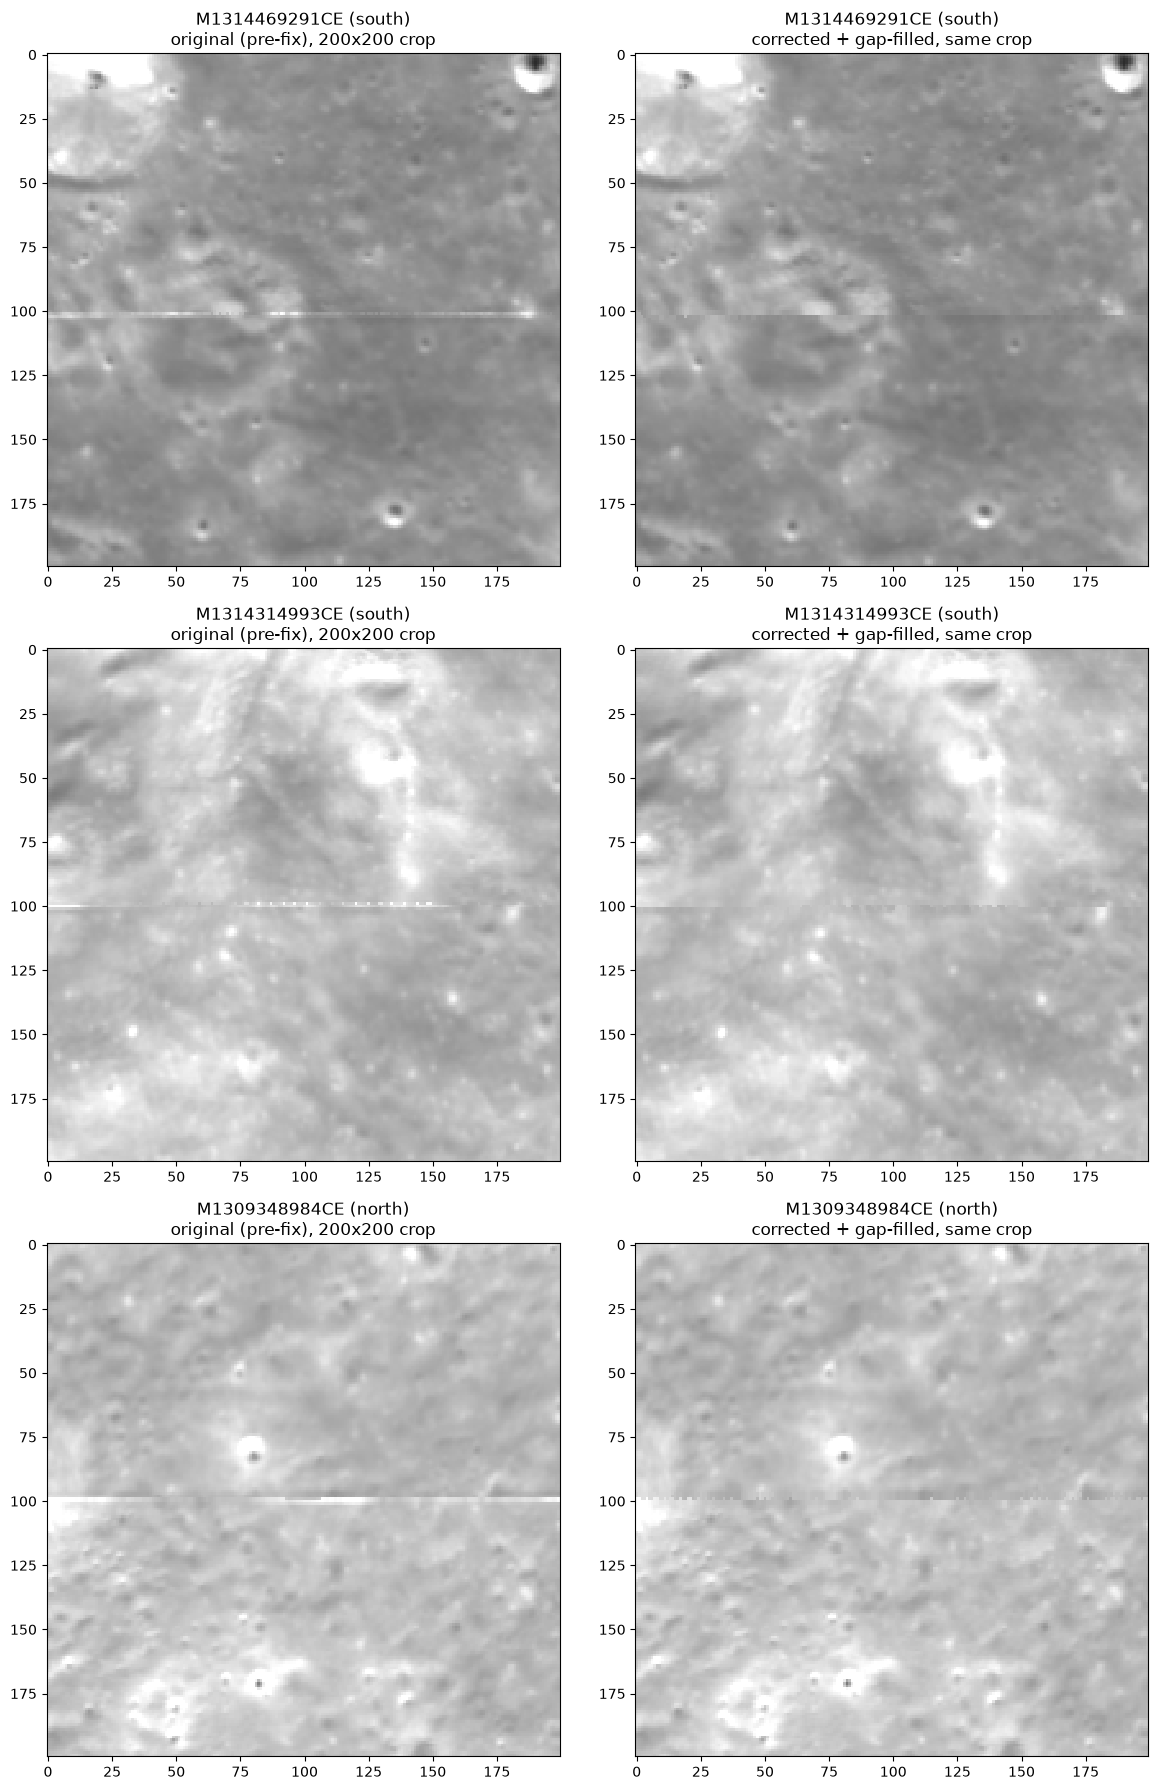

In [4]:
fig, axes = plt.subplots(len(entries), 2, figsize=(12, 6 * len(entries)))
for row, (product_id, e) in zip(axes, entries.items(), strict=True):
    original, filled = e["original_array"], e["corrected_merged_filled"]
    row0, col0 = e["seam_row"] - CROP_SIZE // 2, e["dst_width"] // 2 - CROP_SIZE // 2
    original_crop = original[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    filled_crop = filled[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    vmax = np.nanpercentile(original_crop, 99)
    row[0].imshow(original_crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    row[0].set_title(f"{label(product_id, e['hemisphere'])}\noriginal (pre-fix), {CROP_SIZE}x{CROP_SIZE} crop")
    row[1].imshow(filled_crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    row[1].set_title(f"{label(product_id, e['hemisphere'])}\ncorrected + gap-filled, same crop")
plt.tight_layout()

## Did the seam shrink?

Measured on `dem_mosaic`'s own `--first` output (real `NaN` gaps and all), deliberately not the
gap-filled array -- this keeps the metric an arms-length check of the radiometric correction alone,
not of this project's own fill choices.

In [5]:
for product_id, e in entries.items():
    before, after = seam_jump(e["raw_dem_mosaic"]), seam_jump(e["corrected_dem_mosaic"])
    print(
        f"{label(product_id, e['hemisphere'])}: peak row-to-row jump {before:.4f} -> {after:.4f} "
        f"({100 * (1 - after / before):.1f}% smaller)"
    )

M1314469291CE (south): peak row-to-row jump 0.0033 -> 0.0013 (61.3% smaller)
M1314314993CE (south): peak row-to-row jump 0.0037 -> 0.0015 (58.6% smaller)
M1309348984CE (north): peak row-to-row jump 0.0020 -> 0.0013 (36.2% smaller)


## Does the correction open a coverage gap?

`--count` before vs. after, at the seam. A masking-based correction removes pixels that used to
carry (bad) data, so a real question is whether that leaves an actual hole. `fill_nearby_gaps`
closes what the masking opens; any gap still visible here after that fill would be a genuine,
unrelated coverage problem, not a byproduct of this correction.

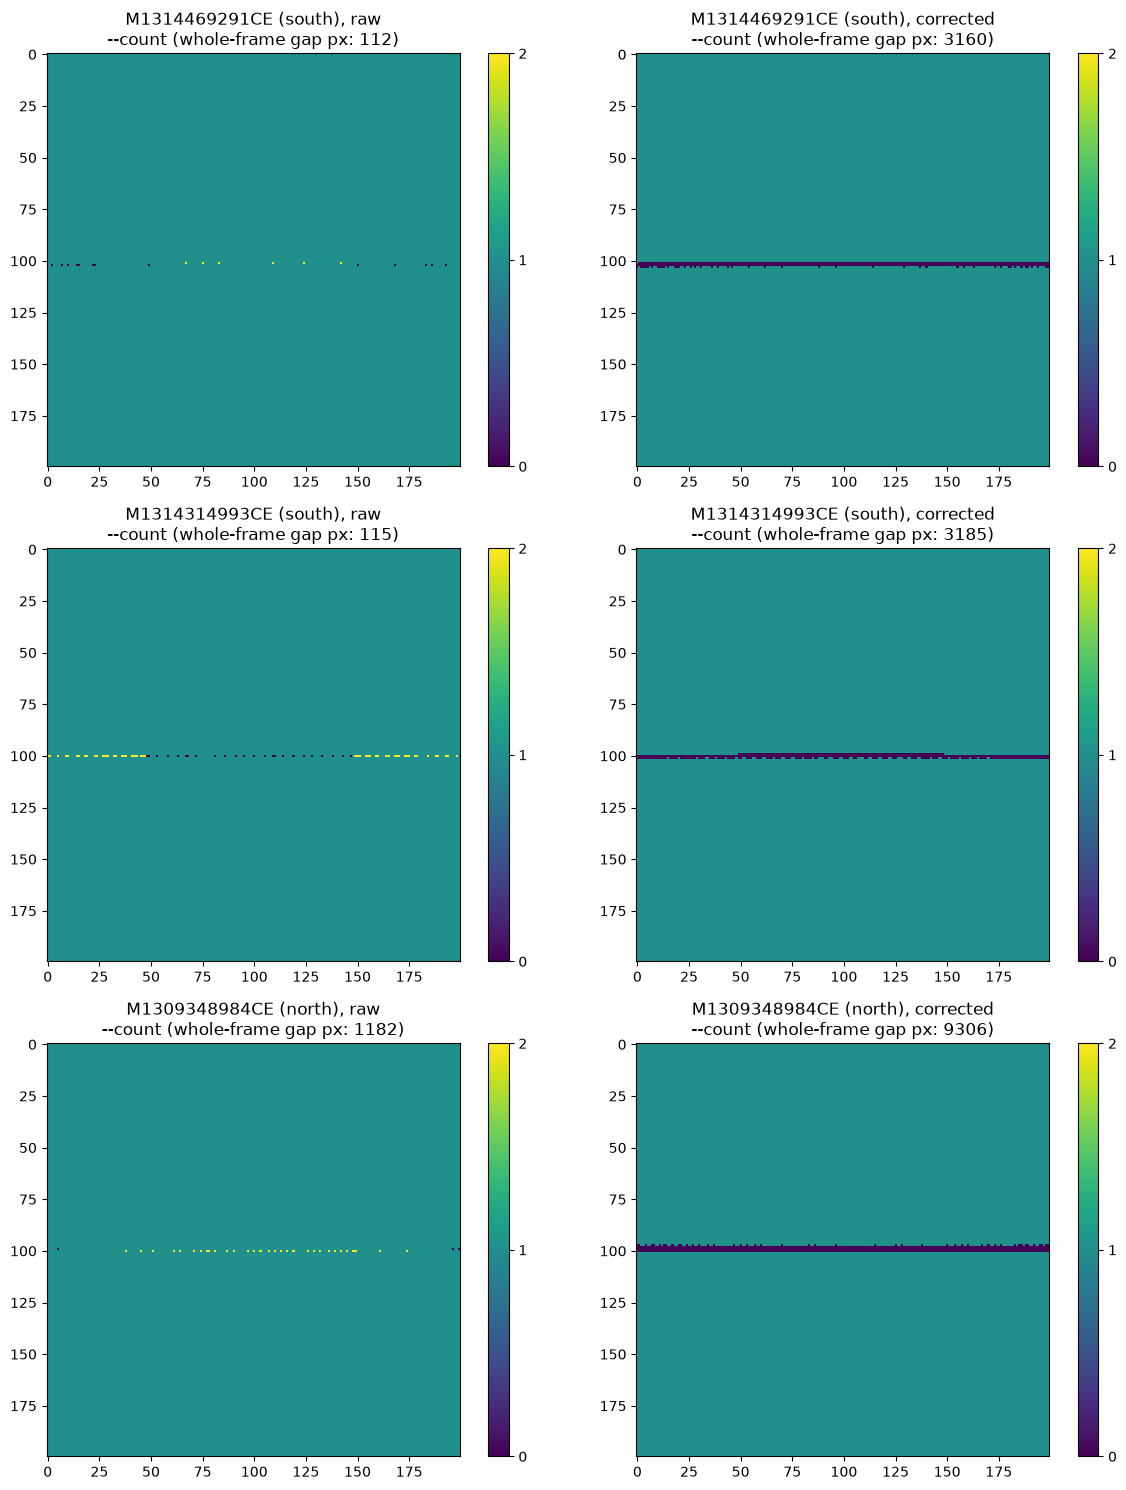

In [6]:
fig, axes = plt.subplots(len(entries), 2, figsize=(12, 5 * len(entries)))
for row, (product_id, e) in zip(axes, entries.items(), strict=True):
    row0, col0 = e["seam_row"] - CROP_SIZE // 2, e["dst_width"] // 2 - CROP_SIZE // 2
    for ax, count_arr, title in zip(row, (e["raw_count"], e["corrected_count"]), ("raw", "corrected"), strict=True):
        crop = count_arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
        im = ax.imshow(crop, cmap="viridis", vmin=0, vmax=2, interpolation="nearest")
        n_gap = int((count_arr == 0).sum())
        ax.set_title(f"{label(product_id, e['hemisphere'])}, {title}\n--count (whole-frame gap px: {n_gap})")
        plt.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046)
plt.tight_layout()

`corrected_merged_filled` (this project's own merge + `fill_nearby_gaps`, computed above) closes
every gap pixel `eligible_gap_fill_mask` scopes to this correction's own masking. Any `NaN` left
after that fill is a separate, pre-existing coverage defect this correction doesn't touch (see
`docs/proposed-tasks/open-items.md`), not something the correction itself failed to close.

In [7]:
for product_id, e in entries.items():
    n_nan = int(np.isnan(e["corrected_merged_filled"]).sum())
    print(f"{label(product_id, e['hemisphere'])}: {n_nan} NaN pixels remaining after fill_nearby_gaps")

M1314469291CE (south): 9 NaN pixels remaining after fill_nearby_gaps
M1314314993CE (south): 10 NaN pixels remaining after fill_nearby_gaps
M1309348984CE (north): 991 NaN pixels remaining after fill_nearby_gaps


## What the correction does to each tile's own near-boundary profile

Binning every valid pixel by its own signed distance from the boundary (native pixels; negative =
equatorward, inside the equirect tile's own valid area; positive = poleward, inside the polar
tile's) shows the correction's effect directly, for `M1314469291CE`'s tile pair: mean reflectance
collapses onto a flat baseline on both sides once the correction runs, in place of the equirect
spike and the polar overshoot/undershoot.

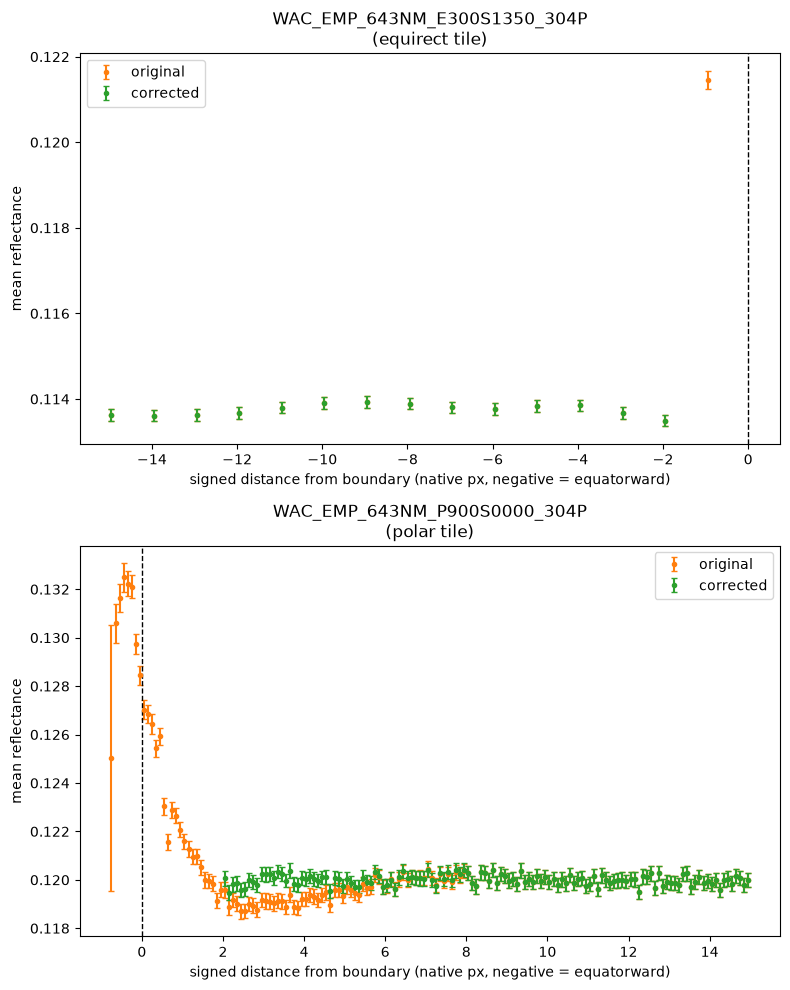

In [8]:
def _bin_profile(distance_px, value, bin_width=0.1, max_distance=15.0):
    bin_edges = np.arange(-max_distance, max_distance + bin_width, bin_width)
    bin_idx = np.digitize(distance_px, bin_edges)
    centers, means, sems = [], [], []
    for b in range(1, len(bin_edges)):
        mask = bin_idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        vals = value[mask]
        centers.append((bin_edges[b - 1] + bin_edges[b]) / 2)
        means.append(vals.mean())
        sems.append(vals.std(ddof=1) / math.sqrt(n) if n > 1 else 0.0)
    return np.array(centers), np.array(means), np.array(sems)


_PROFILE_STRIP_HEIGHT = 512  # polar tiles run ~18669x18669 (~1.3GB); scan in strips, not all at once


def _tile_profile(tile_path, boundary_lat_deg, is_equirect, apply_edge_correction, max_distance_px=15.0):
    """Bin every valid native pixel within `max_distance_px` of `boundary_lat_deg` by its own signed
    distance from the boundary (negative = equatorward), optionally after running the real production
    correction on the same window first -- so the "corrected" curve is the actual masking/model-fit
    code, not a reimplementation."""
    with rasterio.open(tile_path) as src:
        crs, transform = src.crs, src.transform
        nodata = src.nodata if src.nodata is not None else float("nan")
        (x_boundary_m,), (y_boundary_m,) = warp_transform(geo_crs, crs, [0.0], [boundary_lat_deg])
        if is_equirect:
            _, boundary_row = ~transform * (x_boundary_m, y_boundary_m)
            row_lo = max(0, int(math.floor(boundary_row - max_distance_px - 1)))
            row_hi = min(src.height, int(math.ceil(boundary_row + max_distance_px + 1)))
            window = Window(0, row_lo, src.width, row_hi - row_lo)
            strip = src.read(1, window=window)
            masked_out = np.zeros(strip.shape, dtype=bool)
            if apply_edge_correction:
                wac_emp_edge_correction.mask_equirect_edge_row(
                    strip, window_transform(window, transform), crs, MOON_RADIUS_M, nodata, masked_out
                )
            rows = np.arange(row_lo, row_hi)
            per_row = boundary_row - rows if boundary_lat_deg > 0 else rows - boundary_row
            distance = np.broadcast_to(per_row[:, None], strip.shape)
            valid = strip > _REAL_REFLECTANCE_MIN
            return _bin_profile(distance[valid], strip[valid])

        center_col, center_row = (~transform) * (0.0, 0.0)
        pixel_size_m = abs(transform.a)
        boundary_radius_px = math.hypot(x_boundary_m, y_boundary_m) / pixel_size_m
        distances, values = [], []
        for row0 in range(0, src.height, _PROFILE_STRIP_HEIGHT):
            row1 = min(src.height, row0 + _PROFILE_STRIP_HEIGHT)
            window = Window(0, row0, src.width, row1 - row0)
            rows = np.arange(row0, row1).reshape(-1, 1) - center_row
            cols = np.arange(src.width).reshape(1, -1) - center_col
            radius_px = np.sqrt(rows.astype(np.float64) ** 2 + cols.astype(np.float64) ** 2)
            distance = boundary_radius_px - radius_px
            if not (np.abs(distance) <= max_distance_px).any():
                continue
            strip = src.read(1, window=window)
            masked_out = np.zeros(strip.shape, dtype=bool)
            if apply_edge_correction:
                wac_emp_edge_correction.mask_and_correct_polar_edge(
                    strip, window_transform(window, transform), crs, MOON_RADIUS_M, nodata, masked_out
                )
            keep = (strip > _REAL_REFLECTANCE_MIN) & (np.abs(distance) <= max_distance_px)
            distances.append(distance[keep])
            values.append(strip[keep])
        return _bin_profile(np.concatenate(distances), np.concatenate(values))


demo_id = "M1314469291CE"
demo_equirect_id, demo_polar_id = entries[demo_id]["tile_ids"]
demo_boundary_lat = -60.0
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
for ax, tile_id, is_equirect in zip(axes, (demo_equirect_id, demo_polar_id), (True, False), strict=True):
    tile_path = cache.fetch_wac_emp_tile(tile_id, config.cache_root, config.wac_emp_base_url)
    for corrected, color in ((False, "tab:orange"), (True, "tab:green")):
        centers, means, sems = _tile_profile(tile_path, demo_boundary_lat, is_equirect, corrected)
        ax.errorbar(
            centers,
            means,
            yerr=sems,
            fmt="o",
            markersize=3,
            capsize=2,
            color=color,
            label="corrected" if corrected else "original",
        )
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("signed distance from boundary (native px, negative = equatorward)")
    ax.set_ylabel("mean reflectance")
    ax.set_title(f"{tile_id}\n({'equirect' if is_equirect else 'polar'} tile)")
    ax.legend()
plt.tight_layout()

## Conclusion

The correction removes the equirect tile's single-row spike outright and flattens the polar tile's
overshoot/undershoot onto its own local baseline, closes the coverage gap the masking opens, and
shrinks the seam's peak row-to-row jump 36-61% across the three entries validated here (two
`trntest1` south entries, one `trntest2` north entry) -- see the printed numbers above for the exact
figures. `M1309348984CE` (north) shows the smallest improvement: its masked equirect row maps into
only a narrow swath of that entry's destination grid rather than the full width, so this whole-row
metric understates how well the correction works on the pixels it actually touches. `trntest2` is
not regenerated to pick this fix up as part of this notebook.

What the correction doesn't touch, tracked in `docs/proposed-tasks/open-items.md`: why the archived
tiles have this defect in the first place (USGS/ASU's own production pipeline, out of scope here),
and a separate tile-precedence-flicker effect from the two tiles' jagged, locally-diagonal coverage
boundary in the destination grid.